In [4]:
from qeep import plot
from qeep import qeutils

import matplotlib.pyplot as plt

import numpy as np

import matplotlib.pyplot as plt

import yaml
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

from qeep import biases
from qeep import qeresults as qres
import jax
from jax import numpy as jnp


from qeep import fisher, forecast as fore, biases

import os
os.environ['PATH'] = os.path.expanduser("~/texlive/2025/bin/aarch64-linux") + ":" + os.environ['PATH']

style_path = "paper.mplstyle"
plt.style.use(style_path)

In [7]:
def get_fisher(key_main, bGXA = 0, bGXB = 0, bSXA = 2, bSXB = 1, bTXA = 0, bTXB = 0):
    #configuration = '../../configs/abacus/config_desi_example_forecast_base.yaml'
    #i, j = 7, 3
    #configuration = f'../../configs/abacus/desi_nbars/config_desi_base_{i}_{j}_opt.yaml'
    #configuration = f'../../configs/abacus/desi_nbars/config_desi_base_{i}_{j}.yaml'

    configuration = '../../configs/abacus/config_desi_example_forecast_base_with_shift.yaml'

    
    fac = 1
    X = fore.Forecaster(configuration, shot_noise_A = fac, shot_noise_B = fac, variance_factor = fac, bispectrum_factor = 0, trispectrum_factor = 0)
    
    Ks = X.Ks
    
    with open(configuration, 'r') as f:
        config = yaml.safe_load(f)
    QR = qres.QEResults(config, relative_path="../.")
    
    print(config["number_density"]["nbar_A"], config["k_range"]["kmax"])
    
    #plt.loglog(Ks, QR.get_get_bispectrum_mixed_withB()("n"))
    #plt.loglog(Ks, QR.get_get_bispectrum_mixed()("n"))
    
    
    biases_dict = config["bias"]
    number_density = config["number_density"]
    
    nbar_A = number_density["nbar_A"]
    nbar_B = number_density["nbar_B"]
    
    b1A = biases_dict["b10_A"]
    b1B = biases_dict["b10_B"]
    e = 0
    
    #b2A, b2B = -0.3, -0.3
    b2A, b2B = biases.b2_fit(b1A), biases.b2_fit(b1B)
    bs2A, bs2B = biases.bs2_coev(b1A), biases.bs2_coev(b1B)
    
    #bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = 0, 0, 2, 1, 0, 0 
    #bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = 2, 1, 2, 1, 2, 1
    
    keys = ["g", "s", "t", "ga", "sa", "ta"]
    
    v_fiducial = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])
    
    key = key_main
    key2 = None
    
    CAA, CBB, CRR, CAB, CAR, CBR = X.get_functions(QR, key, key2 = key2)
    
    ps_cross = [CAB, CAR, CBR]
    ps_joint = [CRR, CAB, CAR, CBR]
    ps_cross_full = [CAA, CBB, CAB, CAR, CBR]
    ps_joint_full = [CAA, CBB, CRR, CAB, CAR, CBR] #will use this for the calcs!
    ps_joint_A = [CAA, CRR, CAR]
    
    CAAg, CBBg, CRRg, CABg, CARg, CBRg = X.get_functions(QR, "g", key2 = key2)
    ps_joint_full_growth_only = [CAAg, CBBg, CRRg, CABg, CARg, CBRg]
    ps_joint_A_growth_only = [CAAg, CRRg, CARg]
    
    key = "n"
    _, _, CR2R2, _, CAR2, CBR2 = X.get_functions(QR, key, key2 = key2)
    
    key = "n"
    key2 = "n"
    CRR2 = X.get_functions(QR, key, key2 = key2, wrapped = False)

    key = key_main
    Fisher_results = X.get_all_fisher(v_fiducial, X.Ks, key, key_alt = None, relative_path = "../.")


    #cross-correlation coefficients
    def rho(a, b, c):
        return jnp.sqrt(c(v_fiducial)**2/(a(v_fiducial)*b(v_fiducial)))
    
    #[CAA, CBB, CRR, CAB, CAR, CBR]

    plt.title(key_main)
    plt.plot(Ks, rho(CAA, CBB, CAB), label = "AB")
    plt.plot(Ks, rho(CAA, CRR, CAR), label = "AR")
    plt.plot(Ks, rho(CBB, CRR, CBR), label = "BR")
    plt.xlim(1e-3, 0.2)
    plt.legend()
    plt.show()
    plt.close()

    Cov = fore.get_cov_with_AB(*ps_joint_full)
    F = fisher.FisherCov()
    fisher_sympy = F(Cov, v_fiducial, X.Ks)
    
    return X, Fisher_results, fisher_sympy

0.00017 0.15


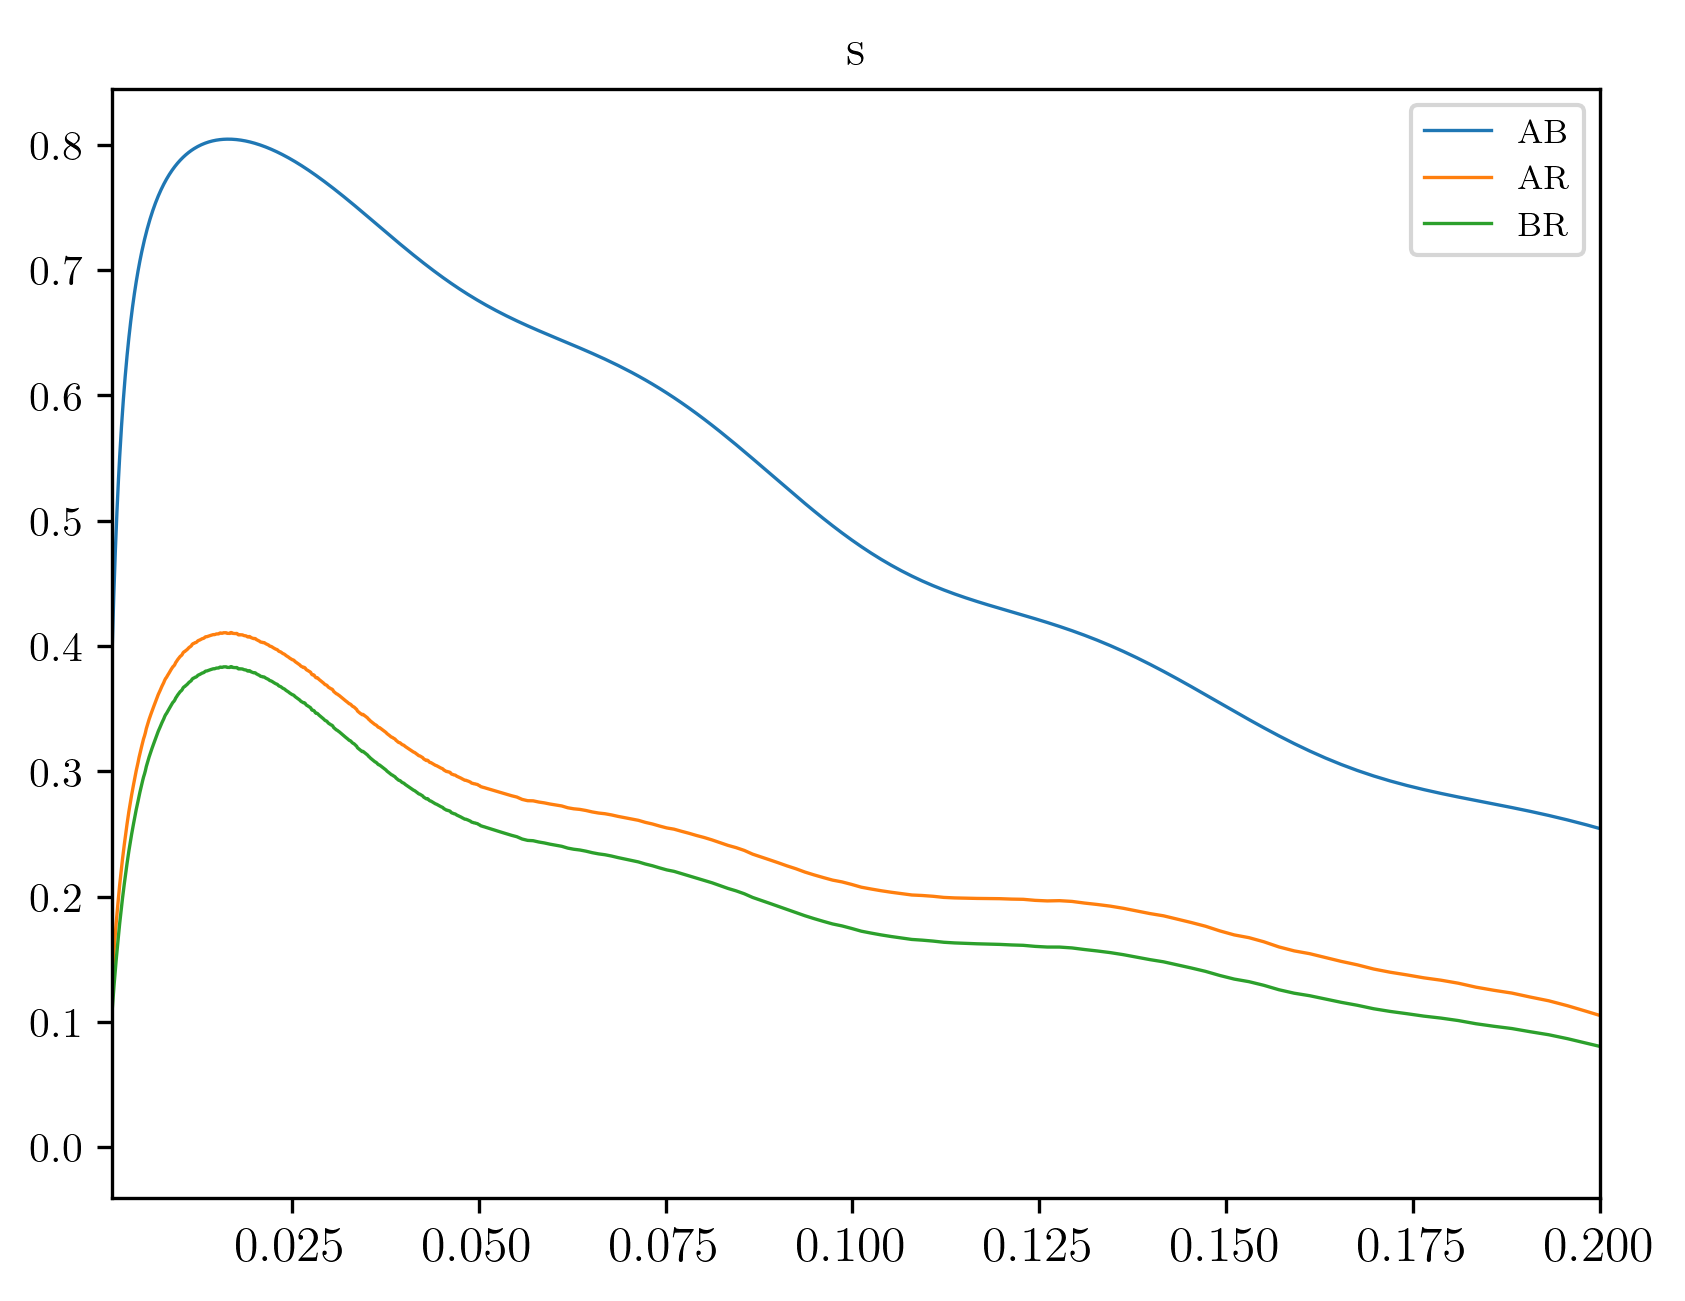

In [8]:
f = {}
fs = {}
key_mains = ["s"]#, "n", "g"]#"sa", "g"]
for key_main in key_mains:
    X, Fisher_results, fisher_sympy = get_fisher(key_main)
    f[key_main] = Fisher_results
    fs[key_main] = fisher_sympy

0.00017 0.15


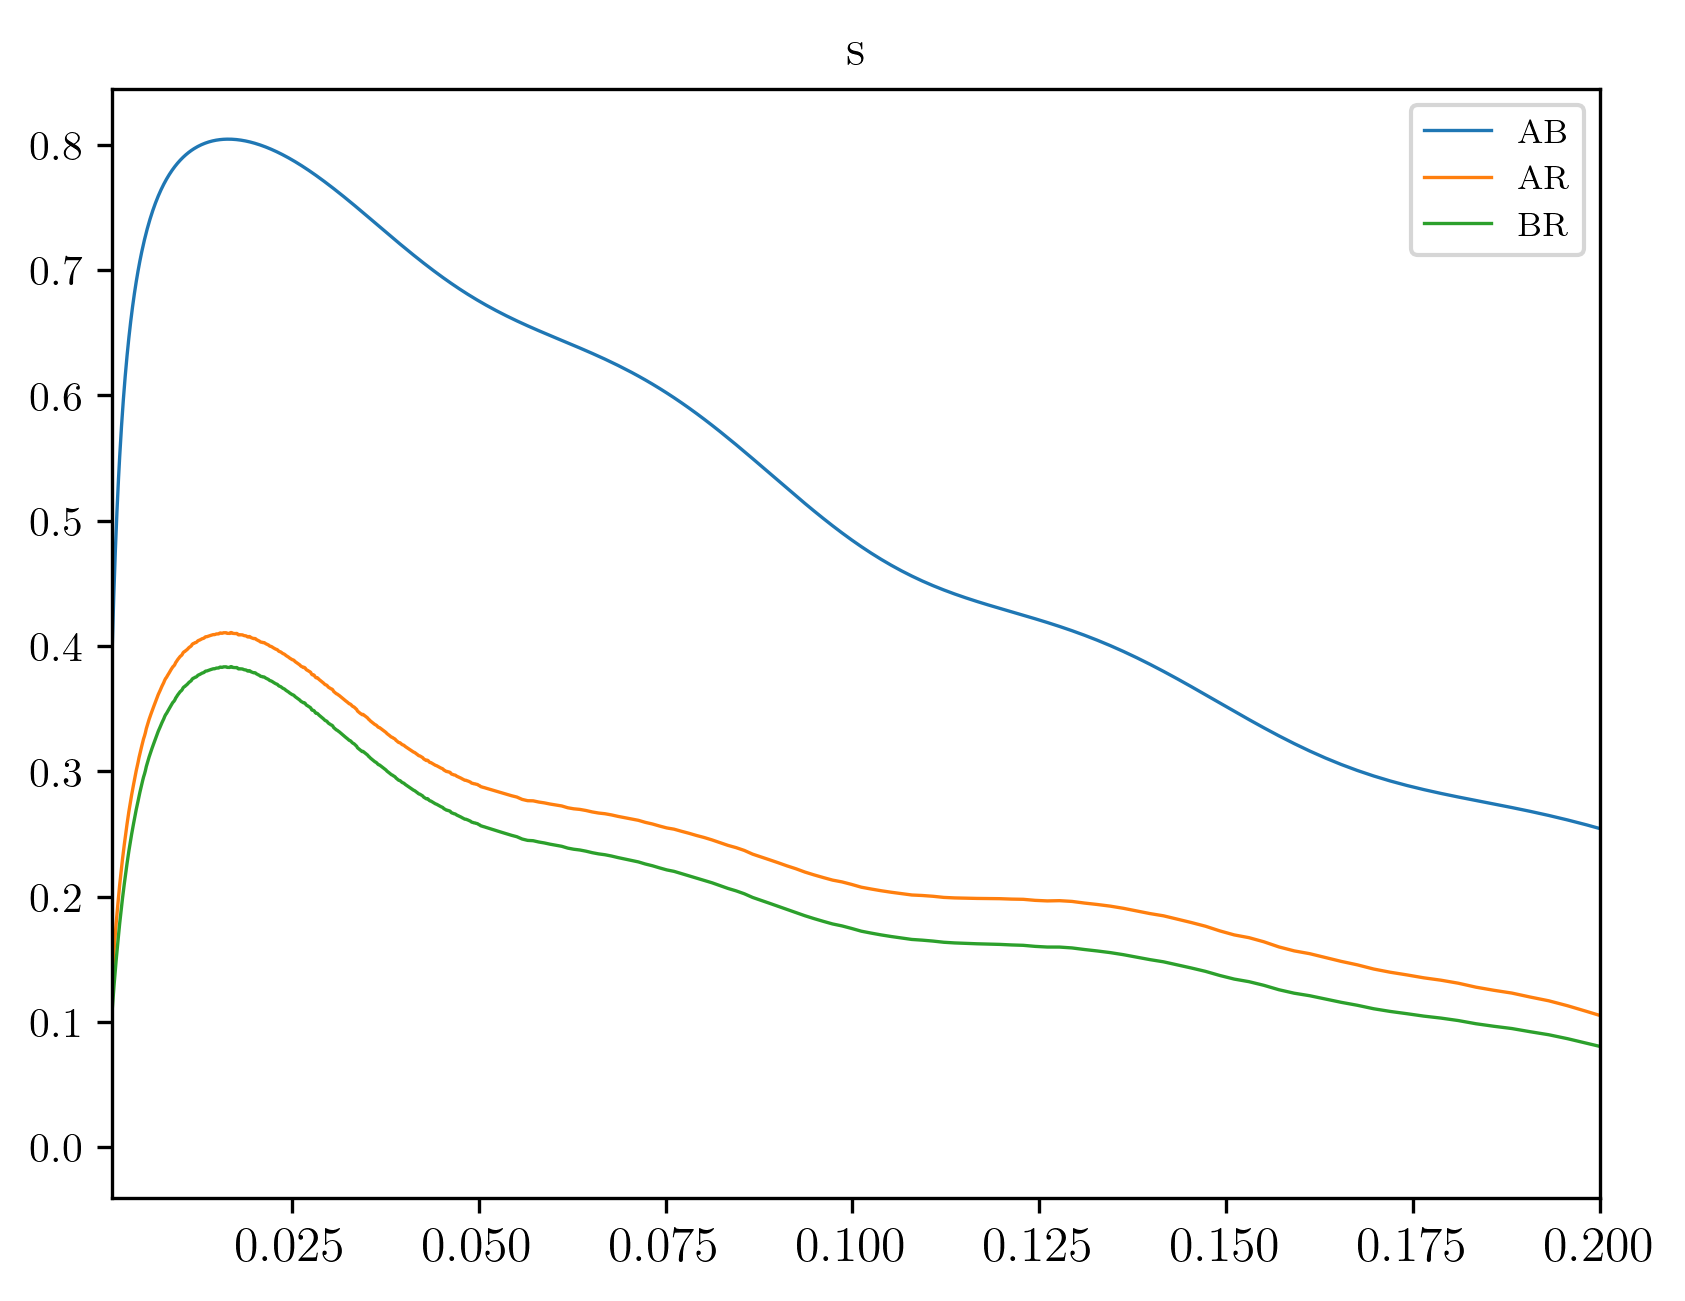

In [9]:
f_new = {}
fs_new = {}
key_mains = ["s"]#, "n", "g"]#"sa", "g"]

b1A = 1.6
b1B = 1.3

bSXA, bSXB = biases.bSX(b1A), biases.bSX(b1B)
bGXA, bGXB = biases.bGX(b1A), biases.bGX(b1B)
bTXA, bTXB = biases.bTX(b1A), biases.bTX(b1B)

for key_main in key_mains:
    X, Fisher_results, fisher_sympy = get_fisher(key_main, bGXA = bGXA, bGXB = bGXB, bSXA = bSXA, bSXB = bSXB, bTXA = bTXA, bTXB = bTXB)
    f_new[key_main] = Fisher_results
    fs_new[key_main] = fisher_sympy

In [10]:
def bGX_from_br(br):
    factor = 203/90
    return br*factor

def bSX_from_br(br):
    factor = 17/6
    return br*factor

def bTX_from_br(br):
    factor = 91/30
    return br*factor


def v_function(v):
    e, b1A, b1B, b2A, b2B, bs2A, bs2B, brA, brB = v
    bGXA, bGXB = bGX_from_br(brA), bGX_from_br(brB)
    bSXA, bSXB = bSX_from_br(brA), bSX_from_br(brB)
    bTXA, bTXB = bTX_from_br(brA), bTX_from_br(brB)
    return jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])

def v_function_identity(v):
    e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = v
    return jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])

In [40]:
#configuration = f'../../configs/abacus/desi_nbars/config_desi_base_{i}_{j}.yaml'

configuration = '../../configs/abacus/config_desi_example_forecast_base_with_shift.yaml'


fac = 1
X = fore.Forecaster(configuration, shot_noise_A = fac, shot_noise_B = fac, variance_factor = fac, bispectrum_factor = 0, trispectrum_factor = 0)

Ks = X.Ks

with open(configuration, 'r') as f:
    config = yaml.safe_load(f)
QR = qres.QEResults(config, relative_path="../.")

print(config["number_density"]["nbar_A"], config["k_range"]["kmax"])

#plt.loglog(Ks, QR.get_get_bispectrum_mixed_withB()("n"))
#plt.loglog(Ks, QR.get_get_bispectrum_mixed()("n"))


biases_dict = config["bias"]
number_density = config["number_density"]

nbar_A = number_density["nbar_A"]
nbar_B = number_density["nbar_B"]

b1A = biases_dict["b10_A"]
b1B = biases_dict["b10_B"]
e = 0#1e-8

#b2A, b2B = -0.3, -0.3
b2A, b2B = biases.b2_fit(b1A), biases.b2_fit(b1B)
bs2A, bs2B = biases.bs2_coev(b1A), biases.bs2_coev(b1B)

br_A, br_B = biases.br_formula(b1A), biases.br_formula(b1B)
v_fiducial_r = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, br_A, br_B])


bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = 0, 0, 2, 1, 0, 0
v_fiducial = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])

bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = 0, 0, 1, 1, 0, 0
v_fiducial_2 = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])

0.00017 0.15


In [41]:
key = "s"
key2 = None
X = fore.Forecaster(configuration, shot_noise_A = fac, shot_noise_B = fac, variance_factor = fac, bispectrum_factor = 0, trispectrum_factor = 0, v_function=v_function_identity)
CAA, CBB, CRR, CAB, CAR, CBR = X.get_functions(QR, key, key2 = key2)
CAA(v_fiducial).shape

F_fid = X.get_all_fisher(v_fiducial, X.Ks, key, key_alt = None, relative_path = "../.")
F_fid_2 = X.get_all_fisher(v_fiducial_2, X.Ks, key, key_alt = None, relative_path = "../.")

In [42]:
X = fore.Forecaster(configuration, shot_noise_A = fac, shot_noise_B = fac, variance_factor = fac, bispectrum_factor = 0, trispectrum_factor = 0, v_function=v_function)
CAA, CBB, CRR, CAB, CAR, CBR = X.get_functions(QR, key, key2 = key2)
F_fid_r = X.get_all_fisher(v_fiducial_r, X.Ks, key, key_alt = None, relative_path = "../.")

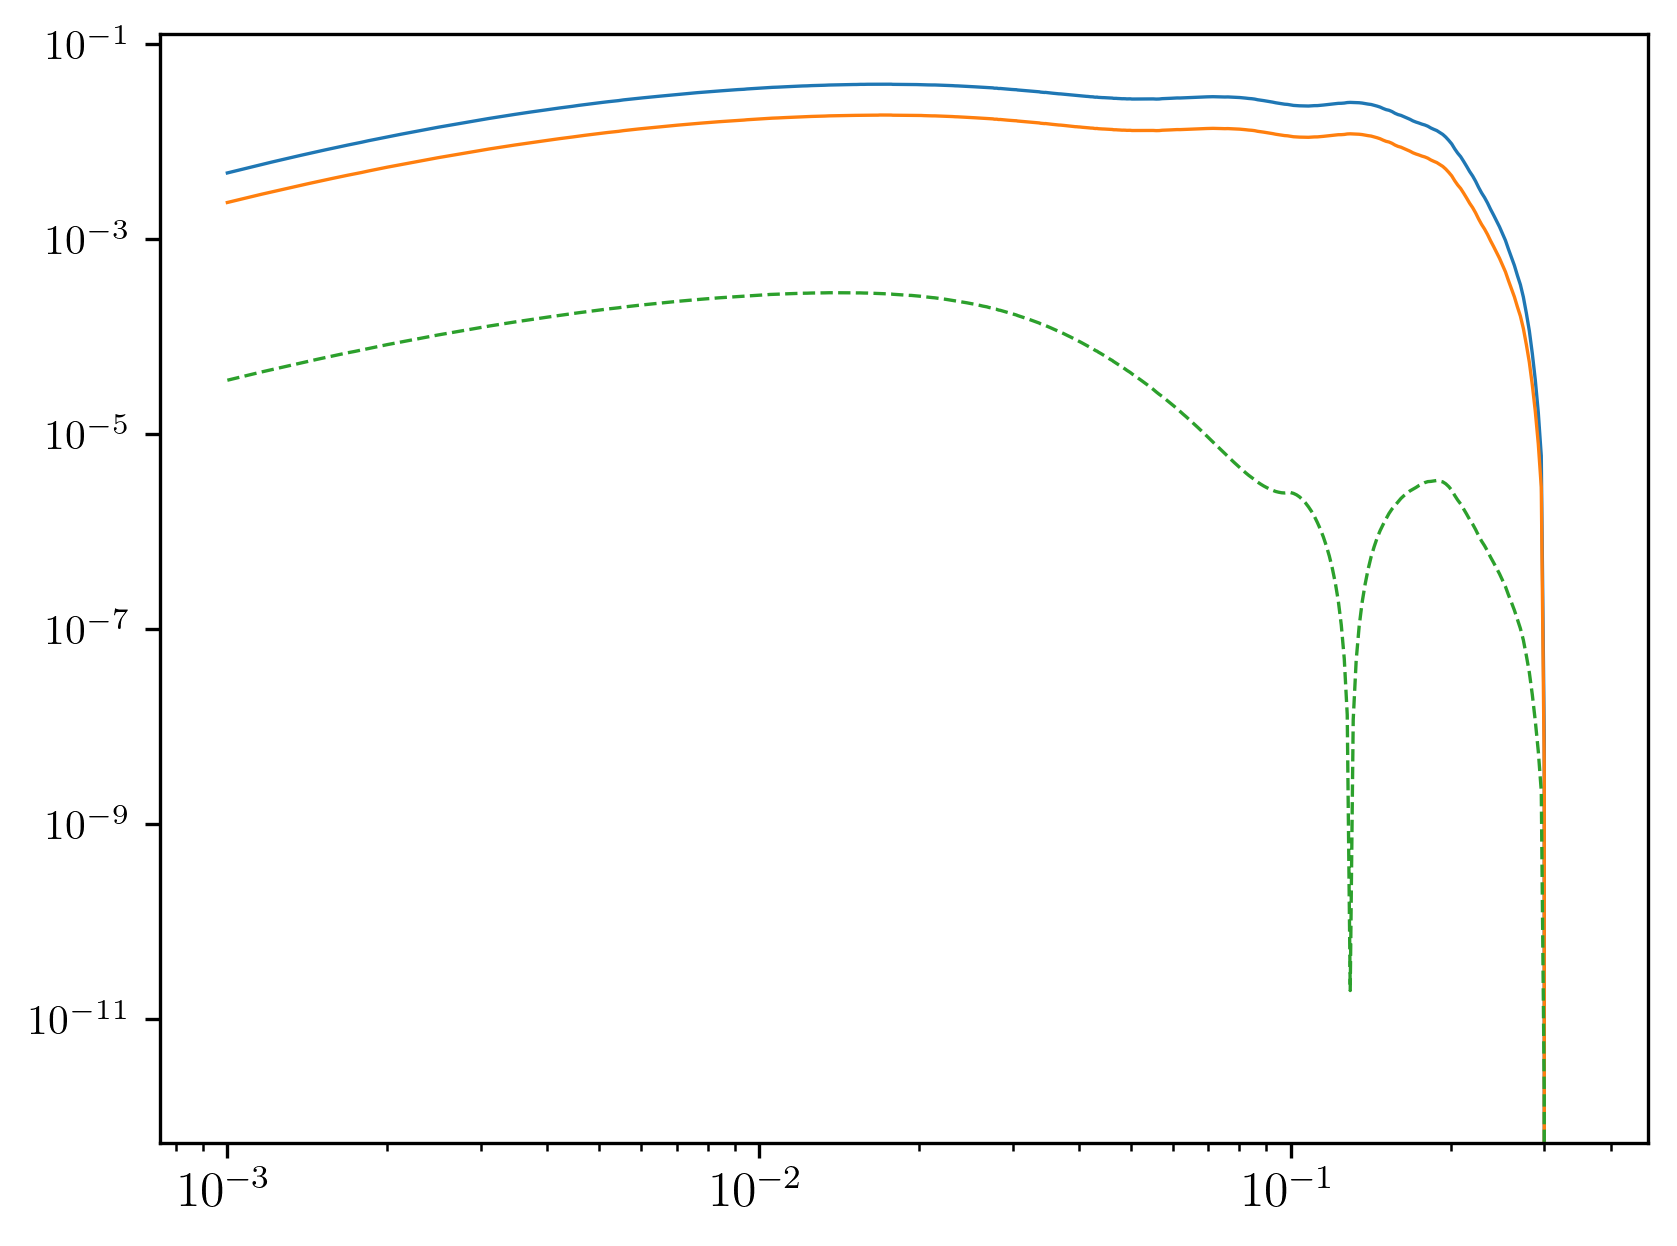

In [43]:
keykk = "F_AA_cross_base"

index = 0
plt.loglog(X.Ks, F_fid[keykk][:, index, index])

plt.loglog(X.Ks, F_fid_2[keykk][:, index, index])

plt.loglog(X.Ks, F_fid_r[keykk][:, index, index], ls = "--")

In [3]:
b1A = 1.6
b1B = 1.3

bSXA, bSXB = biases.bSX(b1A), biases.bSX(b1B)
bGXA, bGXB = biases.bGX(b1A), biases.bGX(b1B)
bTXA, bTXB = biases.bTX(b1A), biases.bTX(b1B)

bSXA, bSXB

(0.11441013460015839, 0.057205067300079196)

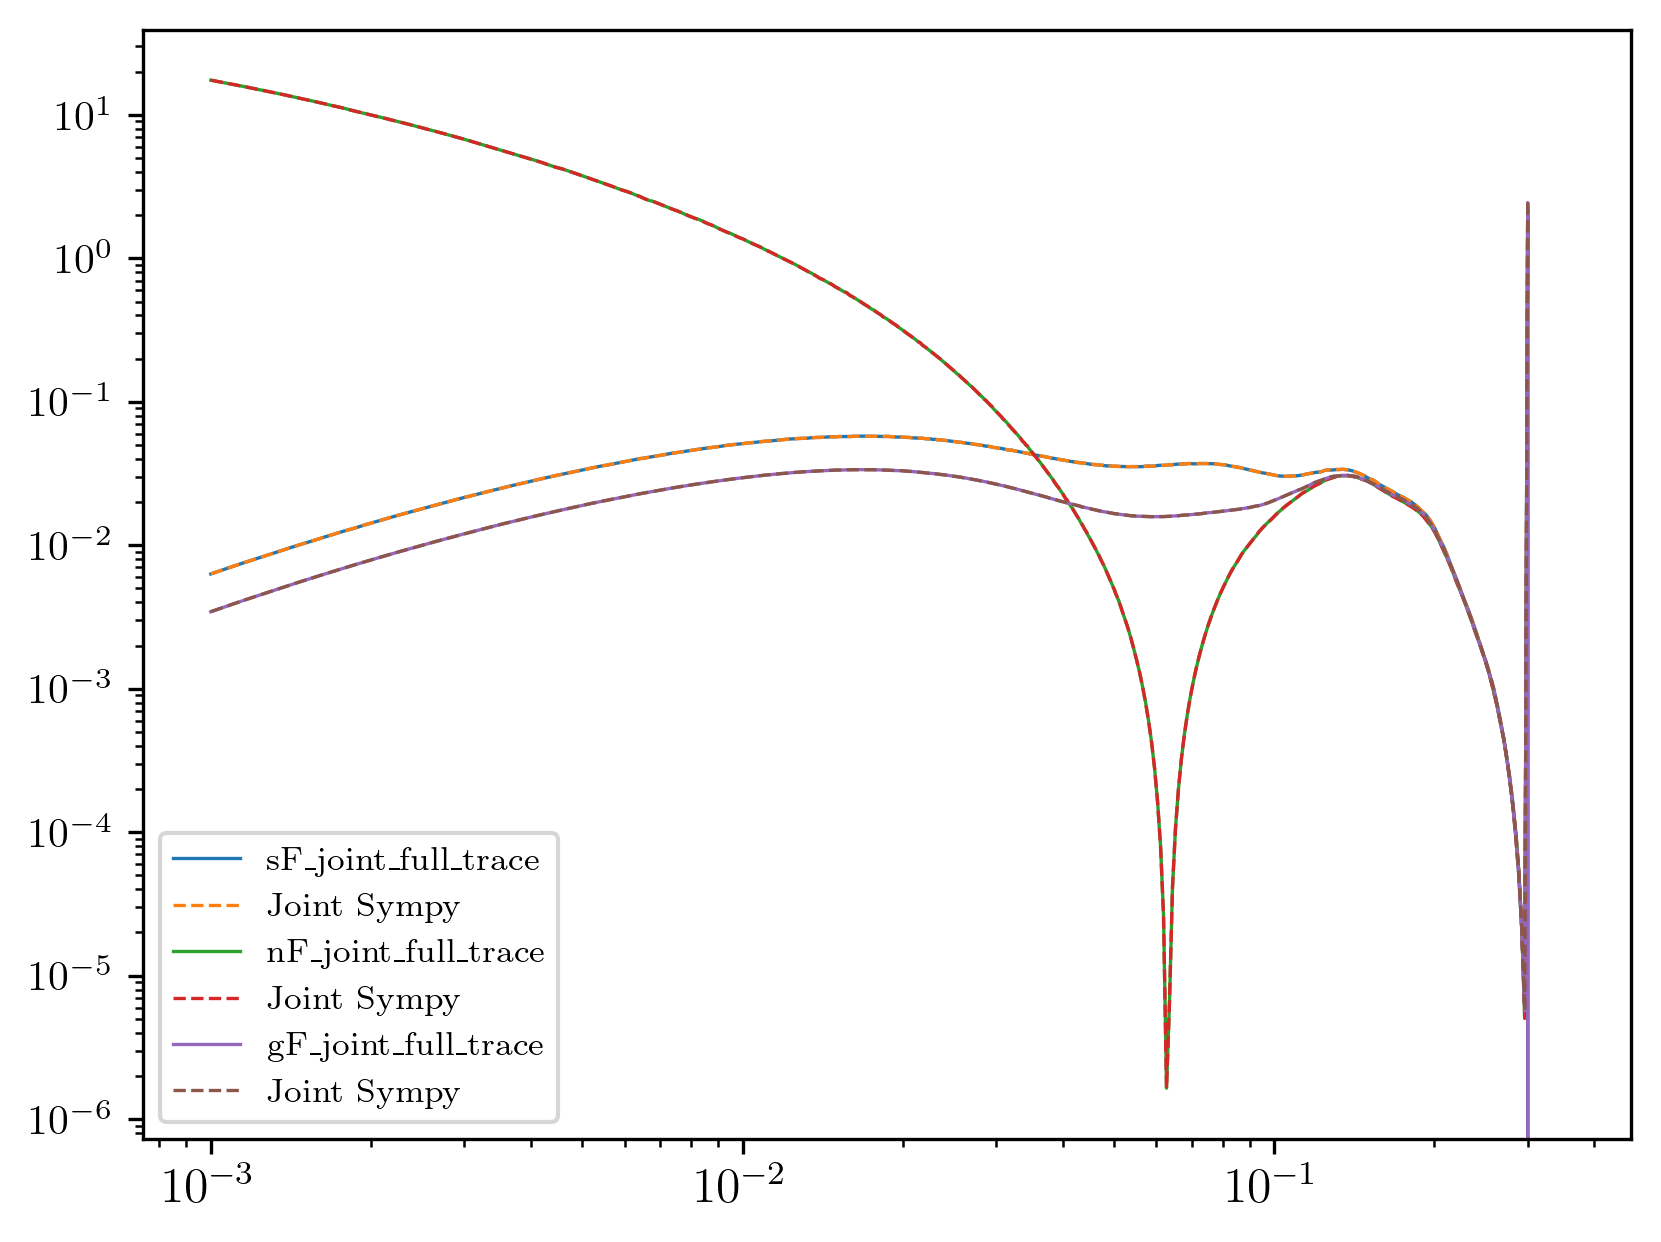

In [6]:
index = 0


for key_main in key_mains:
    Fisher_results = f[key_main]
    fisher_sympy = fs[key_main]
    keys = ["F_joint_full_trace"]#, "F_joint_full_trace", "F_joint_base"]
    for key in keys:
        plt.loglog(X.Ks, Fisher_results[key][:, index, index], label = key_main+key)
    
    plt.plot(X.Ks, fisher_sympy[:, index, index], ls = "--", label = "Joint Sympy")
    plt.legend()
    #plt.show()

Considering br based forecasts using some Bottaro's based model


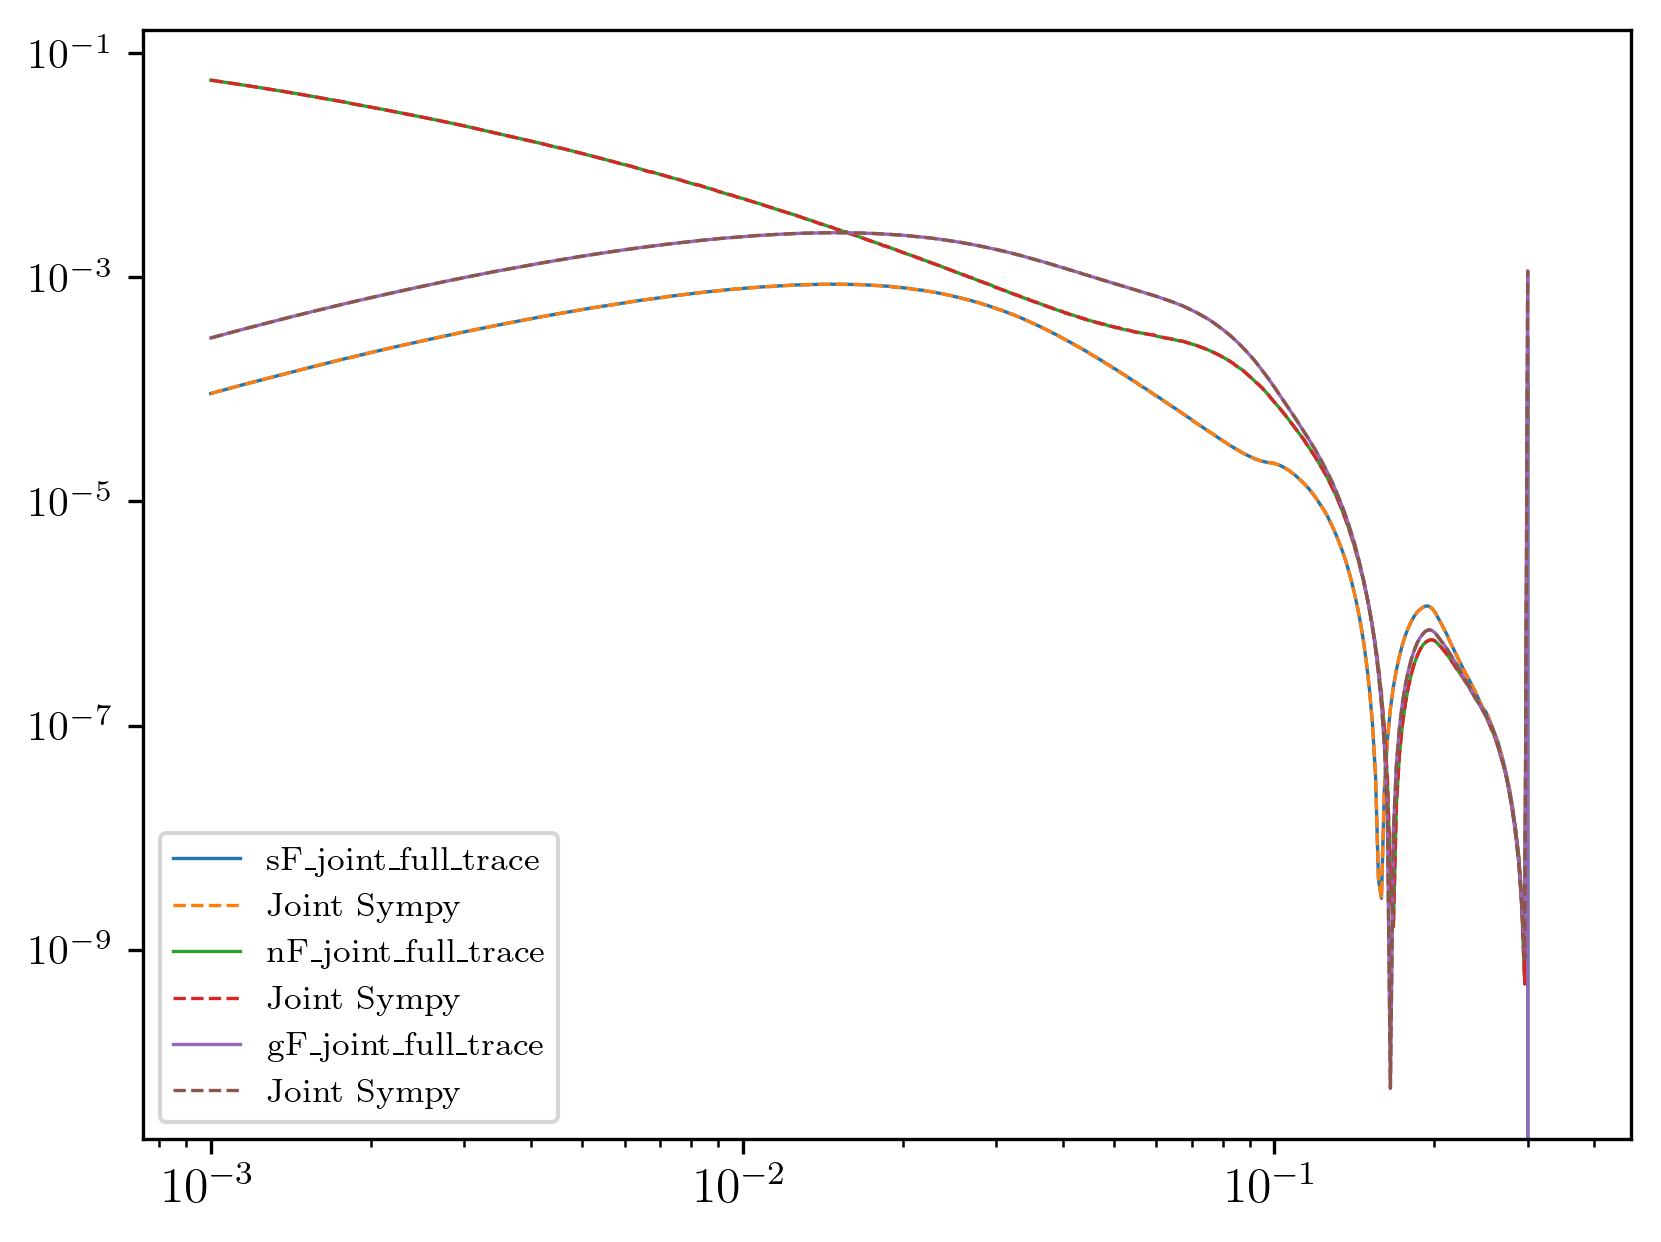

In [8]:
index = 0
print("Considering br based forecasts using some Bottaro's based model")

for key_main in key_mains:
    Fisher_results = f_new[key_main]
    fisher_sympy = fs_new[key_main]
    keys = ["F_joint_full_trace"]#, "F_joint_full_trace", "F_joint_base"]
    for key in keys:
        plt.loglog(X.Ks, Fisher_results[key][:, index, index], label = key_main+key)
    
    plt.plot(X.Ks, fisher_sympy[:, index, index], ls = "--", label = "Joint Sympy")
    plt.legend()
    #plt.show()

In [9]:
def ger_errors(Ks, FisherMatrix, selected, Kmin, Kmax, V, Narr = 50, method = 1):
    modes, F_int = fisher.get_integrated_fisher(Ks, FisherMatrix[:, selected][:, :, selected], Kmin = Kmin, Kmax = Kmax, V = V, Narr = Narr, method = method)
    err_matrix = jnp.array([jnp.diag(F_)**-0.5 for F_ in F_int])
    Cov_int_marg = [jnp.linalg.inv(F_) for F_ in F_int]
    err_marginalized_matrix = jnp.array([jnp.diag(C_)**0.5 for C_ in Cov_int_marg])
    return modes, err_matrix, err_marginalized_matrix, F_int, Cov_int_marg

In [15]:
selected = [0, 1, 2, 3, 4, 5, 6]
Kmax = 0.05

h = 0.67
V = 50  #100*h**3 #in Gpc h^{-3}
V_MPC3 = V*1e9
k_min_analysis = 2*np.pi/V_MPC3**(1/3)
Narr = 1
method = 0

def integrate(f, fs):
    for key_main in key_mains:
        Fisher_results = f[key_main]
        fisher_sympy = fs[key_main]
    
        key = "F_cross_base"
        for key in keys:
            F = Fisher_results[key]
            modes, err_matrix, err_marginalized_matrix, _, _ = ger_errors(X.Ks, F, selected, k_min_analysis, Kmax, V, Narr = Narr, method = method)
            print(key, err_matrix[0, 0], err_marginalized_matrix[0, 0])
        
        modes, err_matrix, err_marginalized_matrix, _, _ = ger_errors(X.Ks, fisher_sympy, selected, k_min_analysis, Kmax, V, Narr = Narr, method = method)
        key = "Joint Sympy"
        print(key_main)
        print(key, err_matrix[0, 0], err_marginalized_matrix[0, 0])
        print("######")

integrate(f, fs)

print("#############")
print("")
print("Considering br based forecasts using some Bottaro's based model")

integrate(f_new, fs_new)


F_cross_base 0.017080671592386965 484.6895189037088
F_joint_full_trace 0.015039241298457049 9.984363778799144
F_joint_base 0.01686149832915308 11.23120938994473
s
Joint Sympy 0.015039241298457047 9.984363757426557
######
F_cross_base 0.009953171735328142 0.030802689371697764
F_joint_full_trace 0.009928246163247167 0.03075832258513649
F_joint_base 0.009952603664967558 0.0307830576724681
n
Joint Sympy 0.009928246163247167 0.030758322584415576
######
F_cross_base 0.023076968476485236 466.24191345243463
F_joint_full_trace 0.020748234823247797 35.270711075032516
F_joint_base 0.02287316668004904 38.69132422187962
g
Joint Sympy 0.020748234823247797 35.270666012785384
######
#############

Considering br based forecasts using some Bottaro's based model
F_cross_base 0.18455241581923798 8472.843611418768
F_joint_full_trace 0.1608867160408046 174.5363507284882
F_joint_base 0.18200382438074067 196.33241891090466
s
Joint Sympy 0.1608867160408046 174.53635256962966
######
F_cross_base 0.112215081412

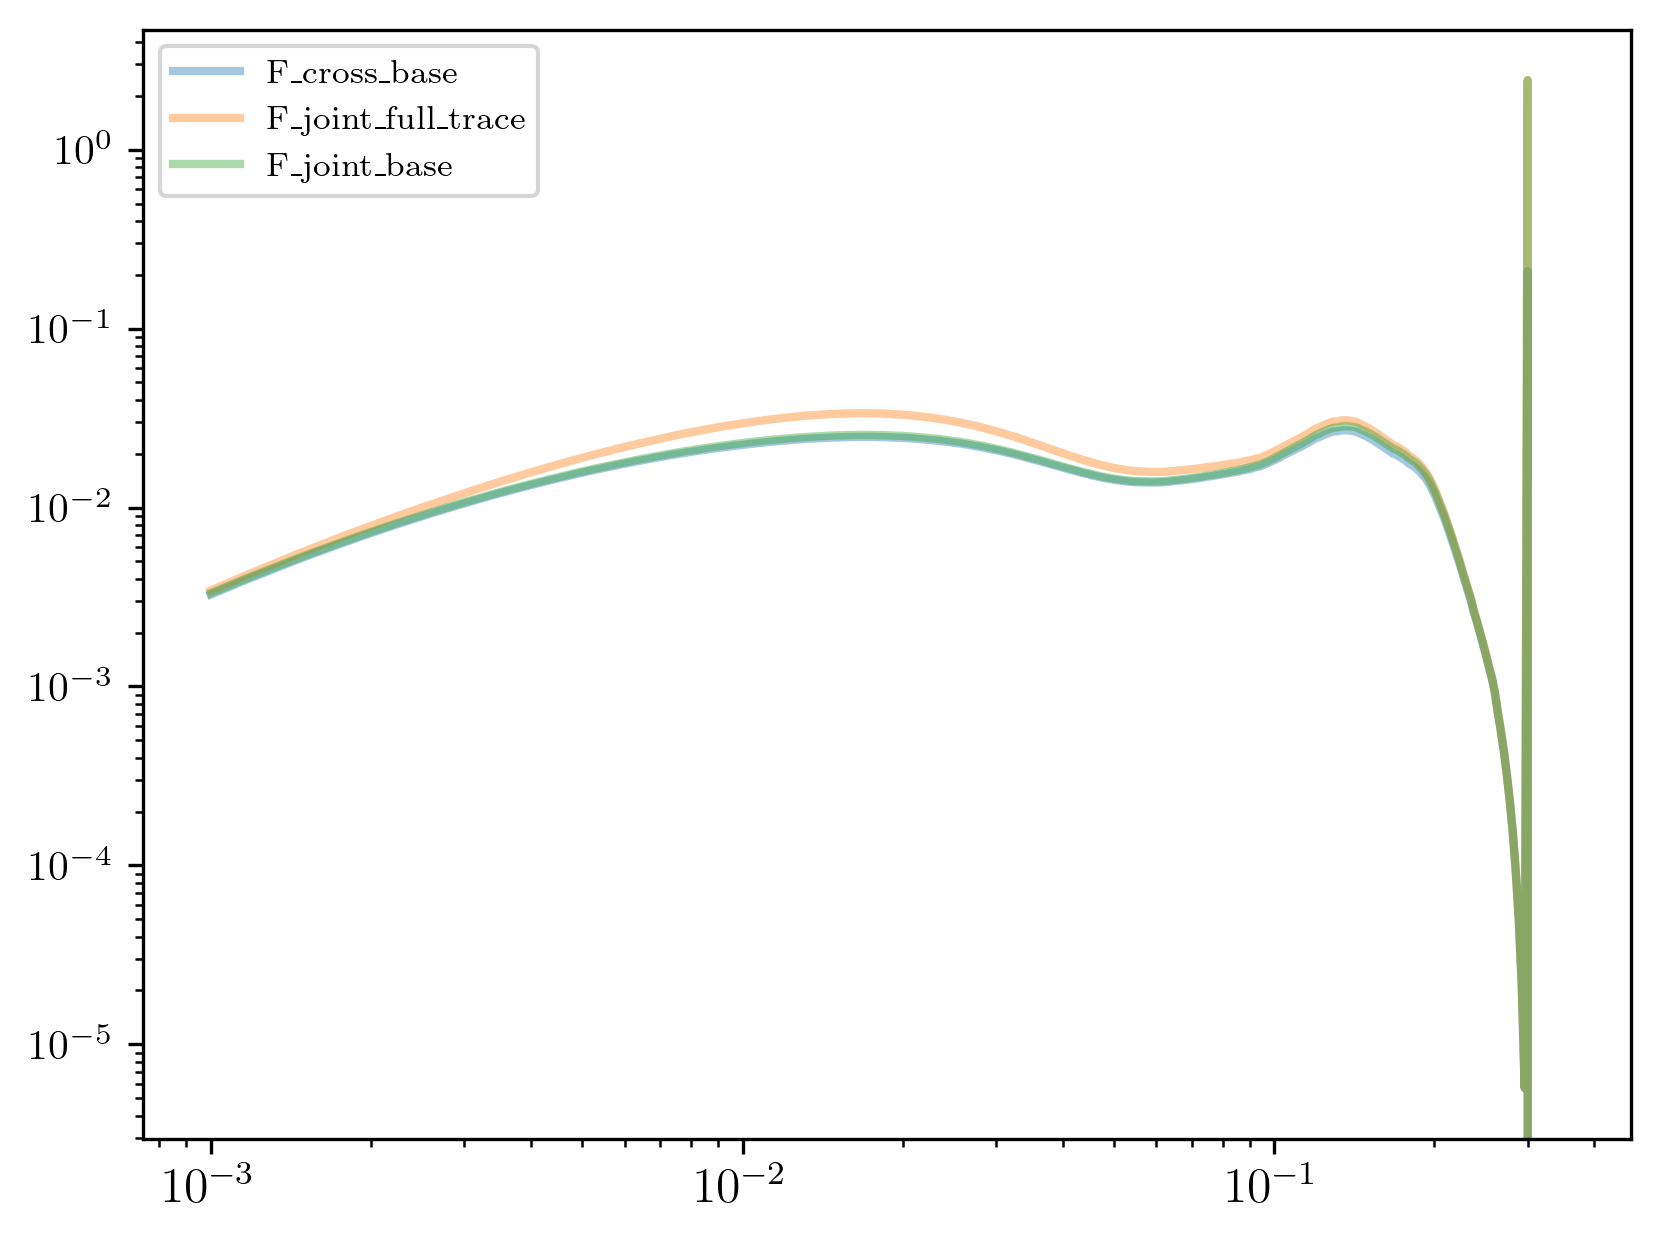

In [14]:
index = 0

Fisher_results = f["g"]

keys = ["F_cross_base", "F_joint_full_trace", "F_joint_base"]
for key in keys:
    p = plt.loglog(X.Ks, Fisher_results[key][:, index, index], label = key, lw = 2, alpha = 0.4)

    #plt.loglog(X.Ks, Fisher_results_other[key][:, index, index], color = p[0].get_color(), ls = "--")

plt.legend()

# Biases

In [30]:
def get_overall_bias(eps, key_fnl, fNL = 0, return_partials = False):

    configuration = '../../configs/abacus/config_desi_example_forecast_base.yaml'
    i, j = 7, 3
    configuration = f'../../configs/abacus/desi_nbars/config_desi_base_{i}_{j}_opt.yaml'
    #configuration = f'../../configs/abacus/desi_nbars/config_desi_base_{i}_{j}.yaml'
    
    
    fac = 1
    X = fore.Forecaster(configuration, shot_noise_A = fac, shot_noise_B = fac, variance_factor = fac, bispectrum_factor = 0, trispectrum_factor = 0)
    
    Ks = X.Ks
    
    with open(configuration, 'r') as f:
        config = yaml.safe_load(f)
    QR = qres.QEResults(config, relative_path="../.")
    
    print(config["number_density"]["nbar_A"], config["k_range"]["kmax"])
    
    #plt.loglog(Ks, QR.get_get_bispectrum_mixed_withB()("n"))
    #plt.loglog(Ks, QR.get_get_bispectrum_mixed()("n"))
    
    
    biases_dict = config["bias"]
    number_density = config["number_density"]
    
    nbar_A = number_density["nbar_A"]
    nbar_B = number_density["nbar_B"]
    
    b1A = biases_dict["b10_A"]
    b1B = biases_dict["b10_B"]
    e = 0
    
    #b2A, b2B = -0.3, -0.3
    b2A, b2B = biases.b2_fit(b1A), biases.b2_fit(b1B)
    bs2A, bs2B = biases.bs2_coev(b1A), biases.bs2_coev(b1B)
    bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = 0, 0, 2, 1, 0, 0 
    #bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = 2, 1, 2, 1, 2, 1
    
    keys_fnl = ["g", "s", "t", "ga", "sa", "ta"]
    keys_symm = ["g", "s", "t"]

    v_fiducial = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])

    fNL = 0

    Cg_dict = {}
    for kk in keys_symm:
        Cg_symm = biases.get_symm_bias(f"{kk}", b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB, fNL = fNL, eps = eps)
        Cg_asymm = biases.get_asymm_bias(f"{kk}", b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB, fNL = fNL, eps = eps)
        Cg_dict[f"{kk}"] = Cg_symm
        Cg_dict[f"{kk}a"] = Cg_asymm
        
    Cg_effective = jnp.hstack([Cg_dict[kk] for kk in keys_fnl])

    normalization = QR.get_get_norm()(key_fnl)
    responses = qres.get_normalization_array(key_fnl, keys_fnl, X.Ks, QR.get_out_normalization_AB())
    
    partials = normalization * responses * Cg_effective[:, jnp.newaxis]
    
    overall_bias = fore.get_tot_bias_Cg(normalization,  Cg_effective, responses)
    if return_partials:
        return overall_bias, partials
    else:
        return overall_bias

In [32]:
bias = lambda eps: get_overall_bias(eps, "n")
der_n = jax.jacfwd(bias)(jnp.array([0.]))

bias = lambda eps: get_overall_bias(eps, "g")
der_g = jax.jacfwd(bias)(jnp.array([0.]))

0.15471962778709272 0.23333333333333334
0.15471962778709272 0.23333333333333334


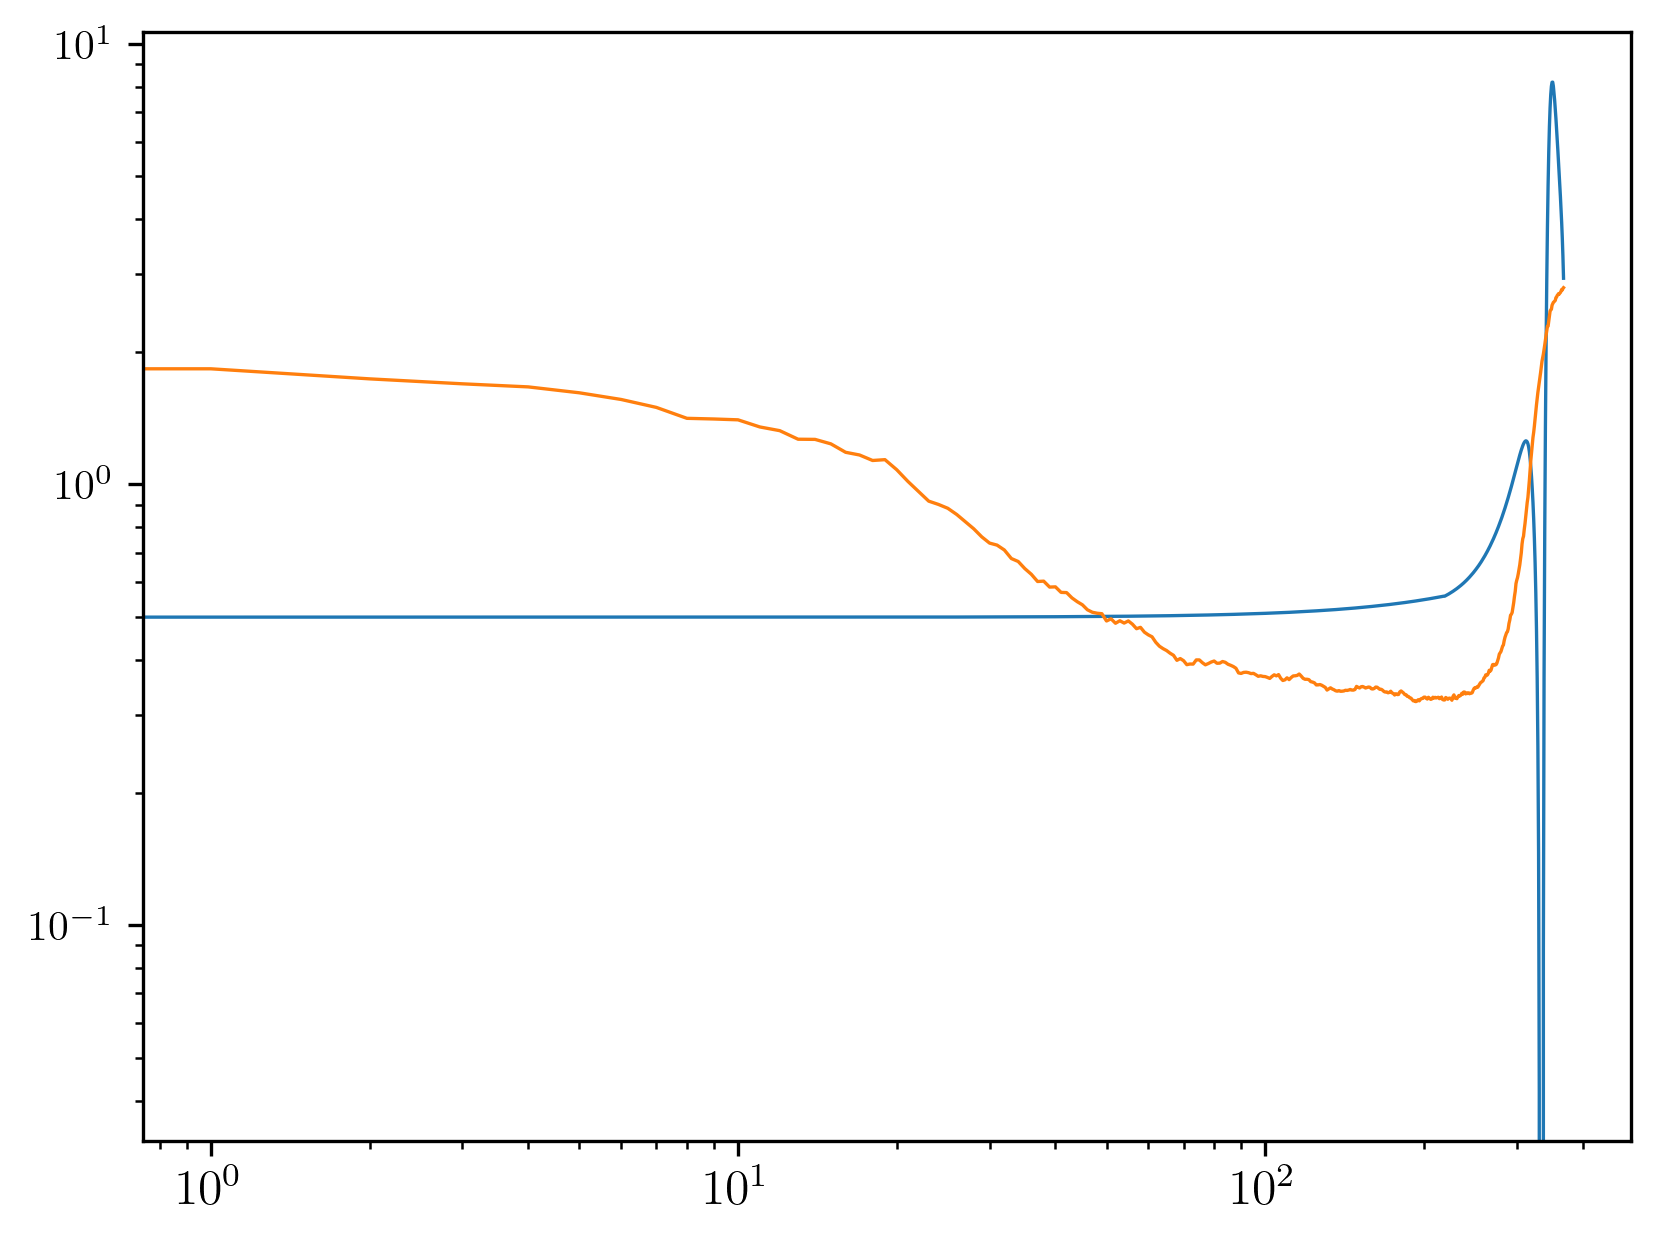

In [41]:
plt.loglog(der_n[:, 0])
plt.loglog(-der_g[:, 0])

0.15471962778709272 0.23333333333333334
0.15471962778709272 0.23333333333333334


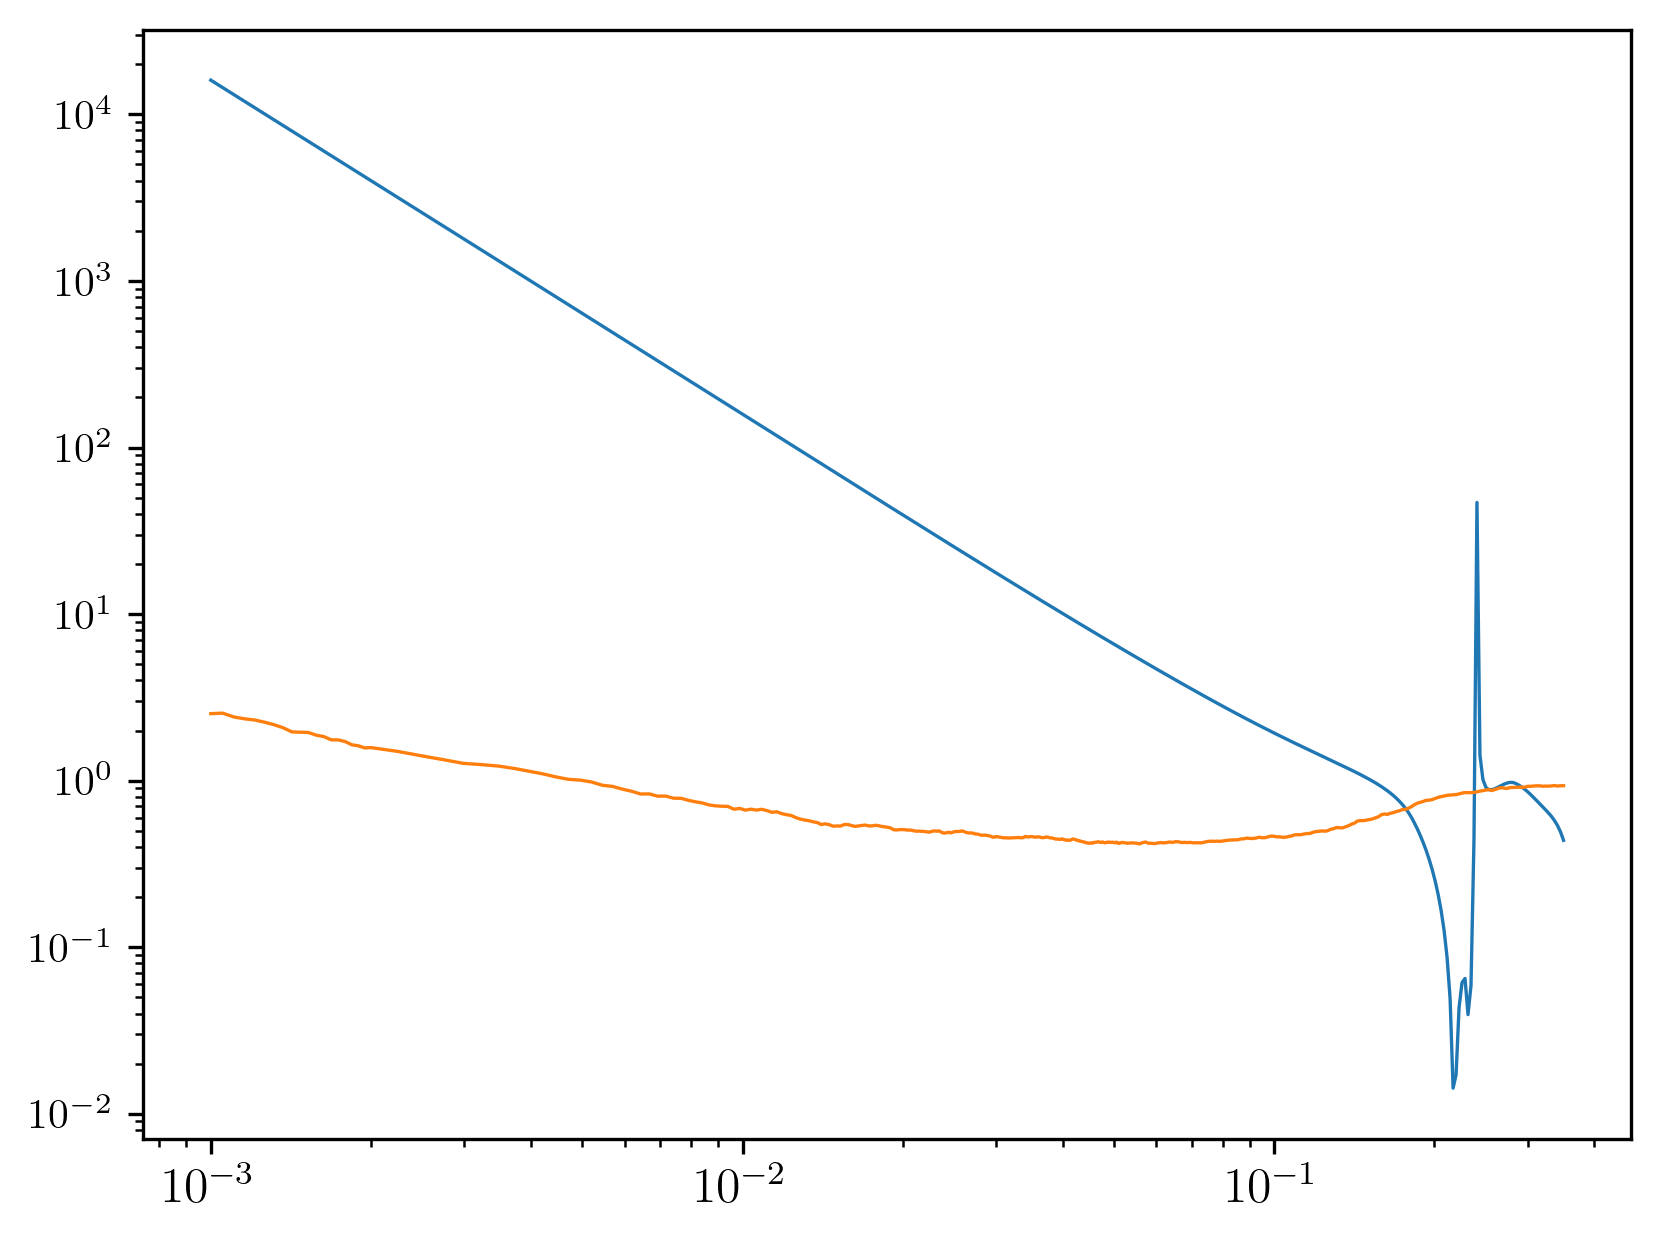

In [38]:
plt.loglog(X.Ks, abs(der_n[:, 0]/get_overall_bias(0, "n")))
plt.loglog(X.Ks, abs(der_g[:, 0]/get_overall_bias(0, "g")))